In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2, x3):
    return x1**2 + 8*x1 + 5*x2**2 + 7*x3**2 + 119.0*x3 + 531.75

def grad(x1, x2, x3):
    return [2*x1 + 8, 10*x2, 14*x3 + 119.0]

def f_next(x, a, p):
    return f(x[0] + a * p[0], x[1] + a * p[1], x[2] + a * p[2])

def sliding_win(x, p):
    a = 0
    h = 0.05
    max_iter = 1000
    for _ in range(max_iter):
        if (f_next(x, a - h, p) > f_next(x, a, p) and f_next(x, a, p) < f_next(x, a + h, p)):
            break
        if (f_next(x, a - h, p) > f_next(x, a + h, p)):
            a += h / 2
        elif (a > -h / 2):
            a -= h / 2 
    return a

def quadratic_interpolation(a, b, pogr, x1, x2, x3):
    while True:
        mid1 = (a + b) / 2
        f_mid1 = f(x1 - mid1 * grad(x1, x2, x3)[0],
                    x2 - mid1 * grad(x1, x2, x3)[1],
                    x3 - mid1 * grad(x1, x2, x3)[2])
        
        f_a = f(x1 - a * grad(x1, x2, x3)[0],
                 x2 - a * grad(x1, x2, x3)[1],
                 x3 - a * grad(x1, x2, x3)[2])
        
        f_b = f(x1 - b * grad(x1, x2, x3)[0],
                 x2 - b * grad(x1, x2, x3)[1],
                 x3 - b * grad(x1, x2, x3)[2])
        
        if abs(b - a) < pogr:
            return mid1
        
        if f_mid1 < f_a and f_mid1 < f_b:
            return mid1
        
        if f_a < f_b:
            b = mid1
        else:
            a = mid1

def grad_descent(a, b, c, pogr):
    x1 = a
    x2 = b
    x3 = c
    
    x_way = [(x1, x2, x3)]
    f_way = [f(x1, x2, x3)]
    
    iters = 0
    
    while True:
        iters += 1
        
        g = grad(x1, x2, x3)
        p = [-g[0], -g[1], -g[2]]
        
        A = sliding_win([x1, x2, x3], p)
        
        alpha = quadratic_interpolation(0, A, pogr, x1, x2, x3)
        
        x1_new = x1 - alpha * g[0]
        x2_new = x2 - alpha * g[1]
        x3_new = x3 - alpha * g[2]
        
        x_way.append((x1_new, x2_new, x3_new))
        f_way.append(f(x1_new, x2_new, x3_new))
        
        if abs(f(x1_new, x2_new, x3_new) - f(x1, x2, x3)) < pogr:
            break
        
        x1, x2, x3 = x1_new, x2_new, x3_new
    
    print('Количество итераций: ', iters)
    return (f(x1_new, x2_new, x3_new), x1_new, x2_new, x3_new, x_way)

x1_start = 8
x2_start = -2
x3_start = 6
pogr = 0.001

f_min, x1_end, x2_end, x3_end, x_way = grad_descent(x1_start, x2_start, x3_start, pogr)
print('Минимум функции: ', f_min)
print('Координаты минимума: ', (x1_end, x2_end, x3_end))


Количество итераций:  16
Минимум функции:  10.000015514873098
Координаты минимума:  (-3.997470387690685, -3.703439204022993e-10, -8.498858826749451)


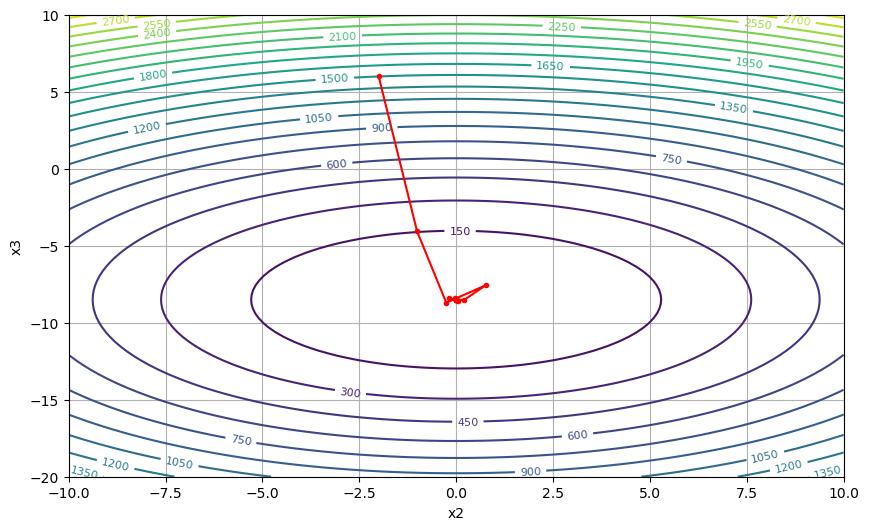

In [4]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(x1_end, X1, X2)

path_x2 = [point[1] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x2, path_x3, 'r.-')

plt.xlabel('x2')
plt.ylabel('x3')

plt.grid()
plt.show()

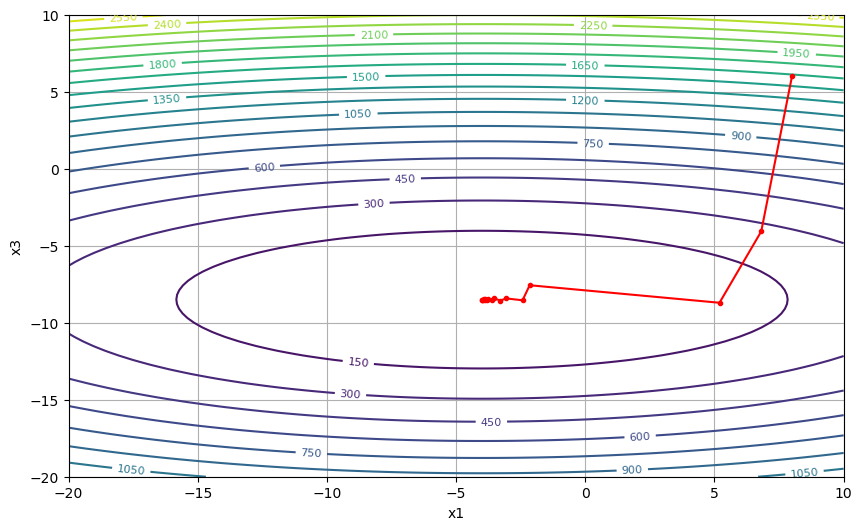

In [5]:
x1_vals = np.linspace(-20, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, x2_end, X2)

path_x1 = [point[0] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x3, 'r.-')

plt.xlabel('x1')
plt.ylabel('x3')

plt.grid()
plt.show()

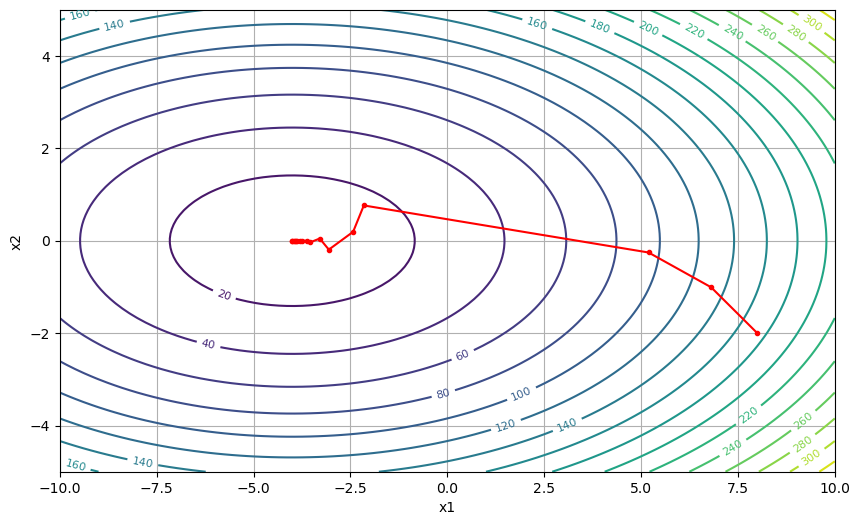

In [6]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2, x3_end)

path_x1 = [point[0] for point in x_way]
path_x2 = [point[1] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x2, 'r.-')

plt.xlabel('x1')
plt.ylabel('x2')

plt.grid()
plt.show()